# Traffic Prediction Project (Simple End-to-End)

This notebook builds a complete and simple machine learning workflow:
1. Load traffic datasets
2. Clean and prepare data
3. Explore traffic patterns
4. Train and compare models
5. Save the best model

Target variable: **`Total`** (total number of vehicles).

In [1]:
# If you get missing package errors, run this once:
# %pip install pandas numpy matplotlib seaborn scikit-learn joblib

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")

In [2]:
# 1) Load data
project_root = Path.cwd()
data_dir = project_root / "Traffic_Dataset"

if not data_dir.exists():
    raise FileNotFoundError(f"Could not find dataset folder: {data_dir}")

traffic_1 = pd.read_csv(data_dir / "Traffic.csv")
traffic_2 = pd.read_csv(data_dir / "TrafficTwoMonth.csv")

print("Traffic.csv shape:", traffic_1.shape)
print("TrafficTwoMonth.csv shape:", traffic_2.shape)

Traffic.csv shape: (2976, 9)
TrafficTwoMonth.csv shape: (5952, 9)


In [3]:
# 2) Combine and clean data

df = pd.concat([traffic_1, traffic_2], ignore_index=True)
df = df.drop_duplicates().reset_index(drop=True)

print("Combined shape after removing duplicates:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values per column:")
print(df.isna().sum())

df.head()

Combined shape after removing duplicates: (6324, 9)

Columns:
['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount', 'TruckCount', 'Total', 'Traffic Situation']

Missing values per column:
Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64


,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [4]:
# 3) Feature engineering

# Convert Time to a numeric hour value (e.g., 13.5 means 1:30 PM)
time_parsed = pd.to_datetime(df["Time"], format="%I:%M:%S %p", errors="coerce")

if time_parsed.isna().any():
    raise ValueError("Some values in 'Time' could not be parsed.")

df["Hour"] = time_parsed.dt.hour + (time_parsed.dt.minute / 60)

# Keep Date numeric (already day number in this dataset)
df["Date"] = pd.to_numeric(df["Date"], errors="coerce")

# Drop any rows that became invalid during parsing/conversion
df = df.dropna().reset_index(drop=True)

print("Shape after feature engineering:", df.shape)
df[["Time", "Hour", "Date", "Day of the week", "Total"]].head()

Shape after feature engineering: (6324, 10)


,Time,Hour,Date,Day of the week,Total
0,12:00:00 AM,0.00,10,Tuesday,39
1,12:15:00 AM,0.25,10,Tuesday,55
2,12:30:00 AM,0.50,10,Tuesday,55
3,12:45:00 AM,0.75,10,Tuesday,58
4,1:00:00 AM,1.00,10,Tuesday,94


              Time         Date Day of the week     CarCount    BikeCount  \
count         6324  6324.000000            6324  6324.000000  6324.000000   
unique          96          NaN               7          NaN          NaN   
top     9:30:00 PM          NaN        Thursday          NaN          NaN   
freq            77          NaN            1020          NaN          NaN   
mean           NaN    16.043327             NaN    64.355629    12.013283   
std            NaN     8.956907             NaN    44.307088    11.363955   
min            NaN     1.000000             NaN     5.000000     0.000000   
25%            NaN     8.000000             NaN    18.000000     3.000000   
50%            NaN    16.000000             NaN    61.000000     9.000000   
75%            NaN    24.000000             NaN   101.250000    19.000000   
max            NaN    31.000000             NaN   180.000000    70.000000   

           BusCount   TruckCount        Total Traffic Situation         Hou

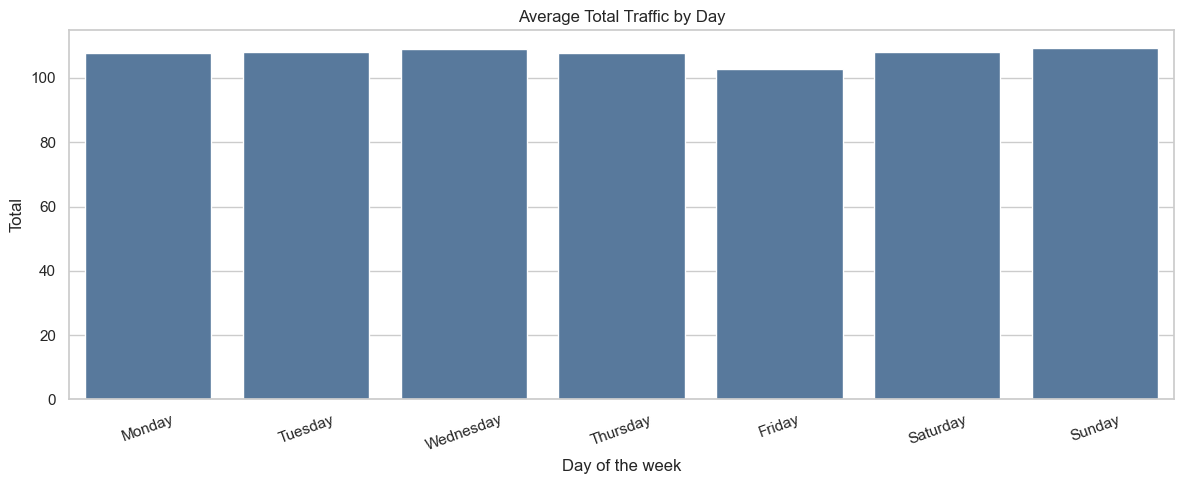

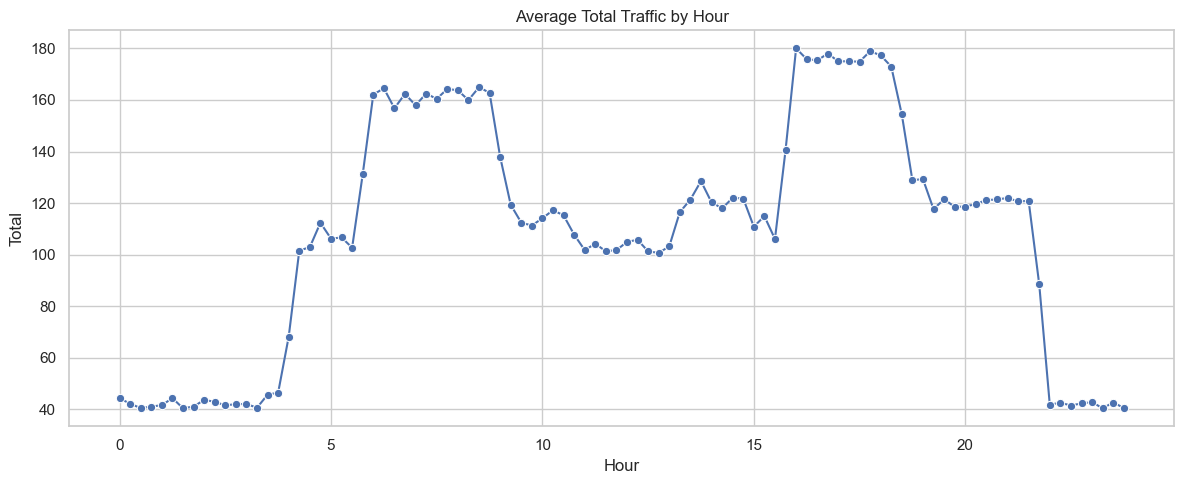

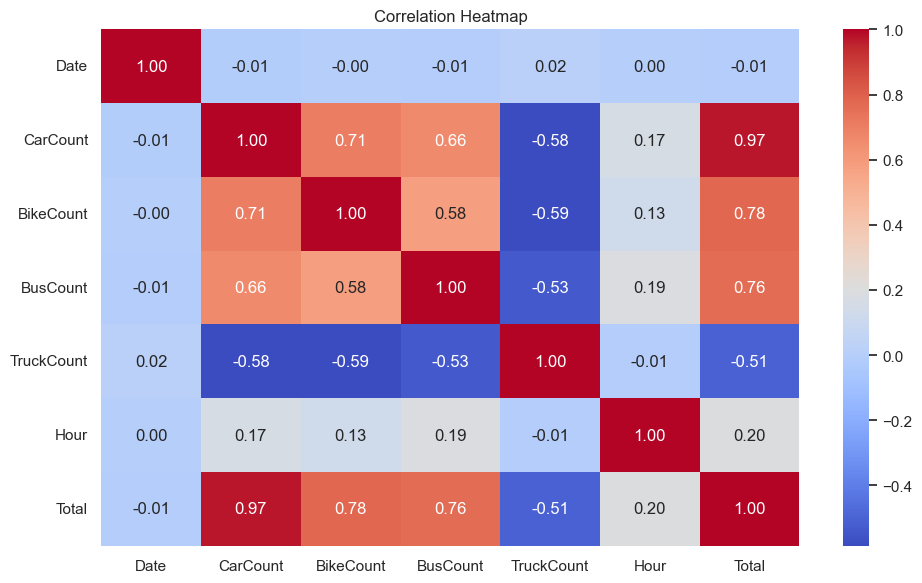

In [6]:
# 4) Quick exploratory data analysis (EDA)

print(df.describe(include="all"))

plt.figure(figsize=(12, 5))

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_by_day = (
    df.groupby("Day of the week", as_index=False)["Total"]
    .mean()
    .sort_values("Day of the week", key=lambda s: s.map({d: i for i, d in enumerate(day_order)}))
)

sns.barplot(data=avg_by_day, x="Day of the week", y="Total", color="#4C78A8")
plt.title("Average Total Traffic by Day")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
avg_by_hour = df.groupby("Hour", as_index=False)["Total"].mean()
sns.lineplot(data=avg_by_hour, x="Hour", y="Total", marker="o")
plt.title("Average Total Traffic by Hour")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
numeric_cols = ["Date", "CarCount", "BikeCount", "BusCount", "TruckCount", "Hour", "Total"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [10]:
# 5) Prepare features and target

# Important: we avoid leakage by NOT using car/bike/bus/truck counts,
# because Total is the sum of those columns.
feature_cols = [
    "Date",
    "Day of the week",
    "Hour",
]

target_col = "Total"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5059, 3)
Test shape: (1265, 3)


In [11]:
# 6) Train two simple models

categorical_features = ["Day of the week"]
numeric_features = ["Date", "Hour"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

print("Models trained successfully.")

Models trained successfully.


In [12]:
# 7) Evaluate models

results = []
all_predictions = {}

for name, pipeline in trained_pipelines.items():
    preds = pipeline.predict(X_test)
    all_predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 4),
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Random Forest,20.709,28.812,0.7274
1,Linear Regression,44.680,54.292,0.0321


Best model: Random Forest


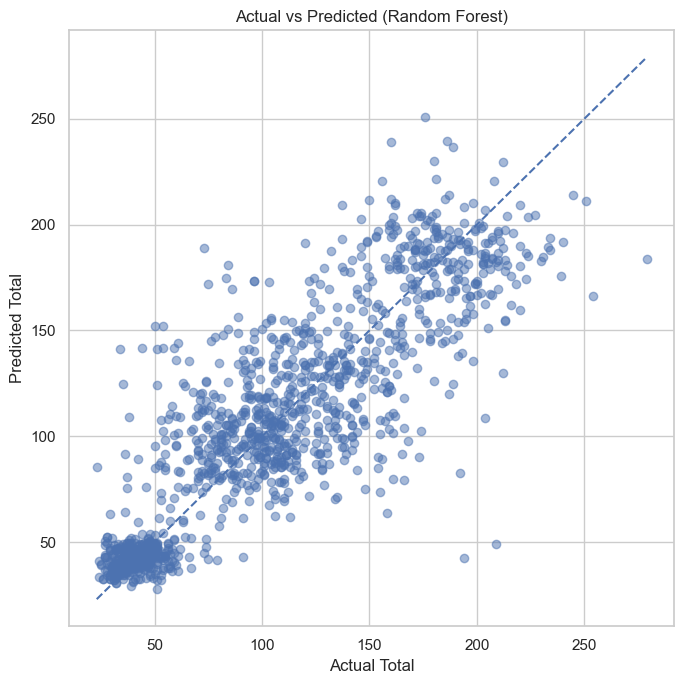

In [13]:
# 8) Pick and visualize the best model

best_model_name = results_df.loc[0, "Model"]
best_model = trained_pipelines[best_model_name]
best_preds = all_predictions[best_model_name]

print(f"Best model: {best_model_name}")

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.5)

min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Total")
plt.ylabel("Predicted Total")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.tight_layout()
plt.show()

In [14]:
# 9) Save the best model

output_path = Path("best_traffic_model.joblib")
joblib.dump(best_model, output_path)
print(f"Saved model to: {output_path.resolve()}")

Saved model to: /Users/youssefbarakat/Documents/GitHub/Big_Data_Project/best_traffic_model.joblib


## Final Notes

- This notebook predicts **`Total`** traffic count.
- It keeps preprocessing and modeling simple and readable.
- You can improve accuracy later by:
  - trying more models (e.g., XGBoost)
  - adding richer time features (peak/off-peak, weekend flag)
  - tuning hyperparameters